# Descriptive Statistics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/00-foundations/statistics/01_descriptive_statistics.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Measures of central tendency: mean, median, mode
- Measures of spread: variance, std dev, range, IQR
- Skewness and kurtosis
- Summary statistics
- Data distribution shapes

## Why Descriptive Statistics?

Before building models, you need to understand your data. Descriptive statistics summarize data in meaningful ways.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print("Descriptive Statistics: Understanding Your Data")

Descriptive Statistics: Understanding Your Data


---
## 1. Central Tendency: Mean, Median, Mode

In [5]:
# Create sample data
data = np.array([1, 2, 2, 3, 3, 3, 4, 4, 5, 100])  # 100 is outlier

mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data).mode

print(f"Data: {data}")
print(f"\nCentral Tendency:")
print(f"  Mean: {mean:.2f}")
print(f"  Median: {median:.2f}")
print(f"  Mode: {mode}")
print(f"\nWhy different?")
print(f"  - Mean affected by outliers (100)")
print(f"  - Median robust to outliers")
print(f"  - Mode = most common value")

Data: [  1   2   2   3   3   3   4   4   5 100]

Central Tendency:
  Mean: 12.70
  Median: 3.00
  Mode: 3

Why different?
  - Mean affected by outliers (100)
  - Median robust to outliers
  - Mode = most common value


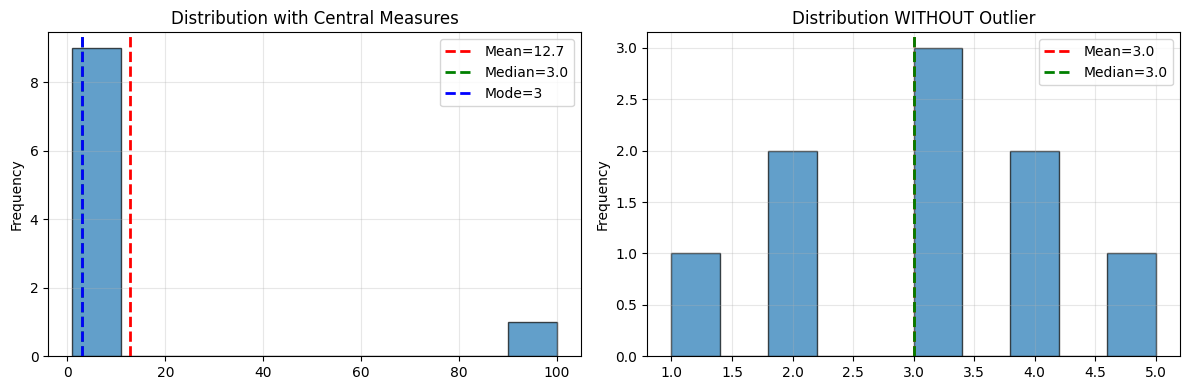

In [6]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data, bins=10, edgecolor='black', alpha=0.7)
axes[0].axvline(mean, color='r', linestyle='--', linewidth=2, label=f'Mean={mean:.1f}')
axes[0].axvline(median, color='g', linestyle='--', linewidth=2, label=f'Median={median:.1f}')
axes[0].axvline(mode, color='b', linestyle='--', linewidth=2, label=f'Mode={mode}')
axes[0].set_title('Distribution with Central Measures')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Without outlier
data_no_outlier = data[:-1]
mean_no = np.mean(data_no_outlier)
median_no = np.median(data_no_outlier)

axes[1].hist(data_no_outlier, bins=10, edgecolor='black', alpha=0.7)
axes[1].axvline(mean_no, color='r', linestyle='--', linewidth=2, label=f'Mean={mean_no:.1f}')
axes[1].axvline(median_no, color='g', linestyle='--', linewidth=2, label=f'Median={median_no:.1f}')
axes[1].set_title('Distribution WITHOUT Outlier')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Measures of Spread

In [7]:
# Variance and Std Dev
variance = np.var(data)
std_dev = np.std(data)
range_val = np.max(data) - np.min(data)

# Quartiles and IQR
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)  # median
q3 = np.percentile(data, 75)
iqr = q3 - q1

print(f"Measures of Spread:")
print(f"  Variance: {variance:.2f}")
print(f"  Std Dev: {std_dev:.2f}")
print(f"  Range: {range_val}")
print(f"\nQuartiles:")
print(f"  Q1 (25%): {q1}")
print(f"  Q2 (50%): {q2} (median)")
print(f"  Q3 (75%): {q3}")
print(f"  IQR (Q3-Q1): {iqr}")

Measures of Spread:
  Variance: 848.01
  Std Dev: 29.12
  Range: 99

Quartiles:
  Q1 (25%): 2.25
  Q2 (50%): 3.0 (median)
  Q3 (75%): 4.0
  IQR (Q3-Q1): 1.75


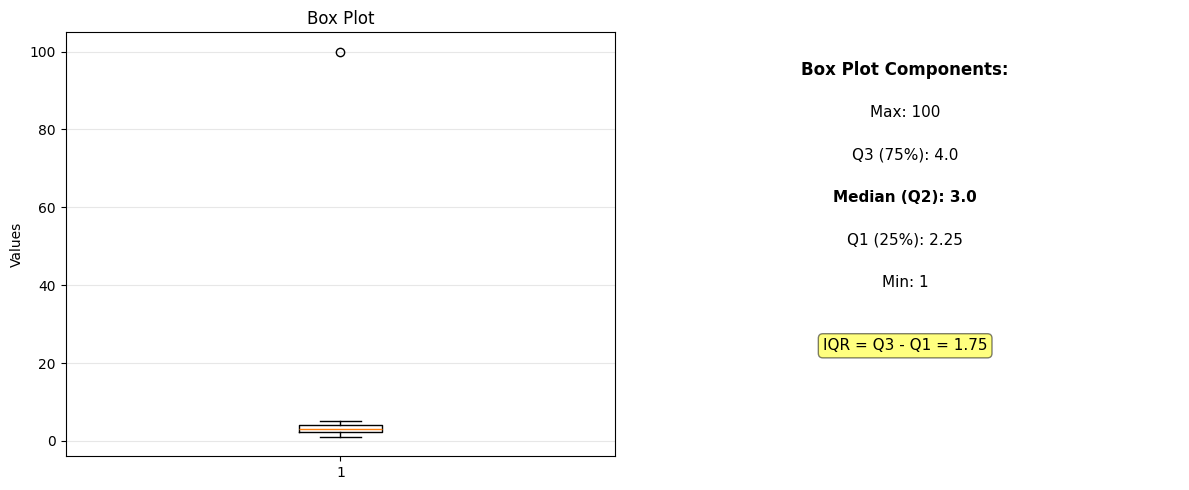

In [8]:
# Box plot visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
axes[0].boxplot(data, vert=True)
axes[0].set_ylabel('Values')
axes[0].set_title('Box Plot')
axes[0].grid(True, alpha=0.3, axis='y')

# Interpretation
axes[1].text(0.5, 0.9, 'Box Plot Components:', ha='center', fontsize=12, weight='bold')
axes[1].text(0.5, 0.8, f'Max: {np.max(data)}', ha='center', fontsize=11)
axes[1].text(0.5, 0.7, f'Q3 (75%): {q3}', ha='center', fontsize=11)
axes[1].text(0.5, 0.6, f'Median (Q2): {q2}', ha='center', fontsize=11, weight='bold')
axes[1].text(0.5, 0.5, f'Q1 (25%): {q1}', ha='center', fontsize=11)
axes[1].text(0.5, 0.4, f'Min: {np.min(data)}', ha='center', fontsize=11)
axes[1].text(0.5, 0.25, f'IQR = Q3 - Q1 = {iqr}', ha='center', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 3. Skewness and Kurtosis

In [9]:
# Skewness = asymmetry of distribution
# Negative = left-skewed, Positive = right-skewed, 0 = symmetric

# Kurtosis = tailedness
# High = heavy tails, Low = light tails

skewness = stats.skew(data)
kurtosis = stats.kurtosis(data)

print(f"Skewness: {skewness:.3f}")
print(f"  > 0: right-skewed (tail on right)")
print(f"  = 0: symmetric")
print(f"  < 0: left-skewed (tail on left)")
print(f"\nKurtosis: {kurtosis:.3f}")
print(f"  > 0: heavy tails (more outliers)")
print(f"  = 0: normal distribution")
print(f"  < 0: light tails (fewer outliers)")

Skewness: 2.660
  > 0: right-skewed (tail on right)
  = 0: symmetric
  < 0: left-skewed (tail on left)

Kurtosis: 5.089
  > 0: heavy tails (more outliers)
  = 0: normal distribution
  < 0: light tails (fewer outliers)


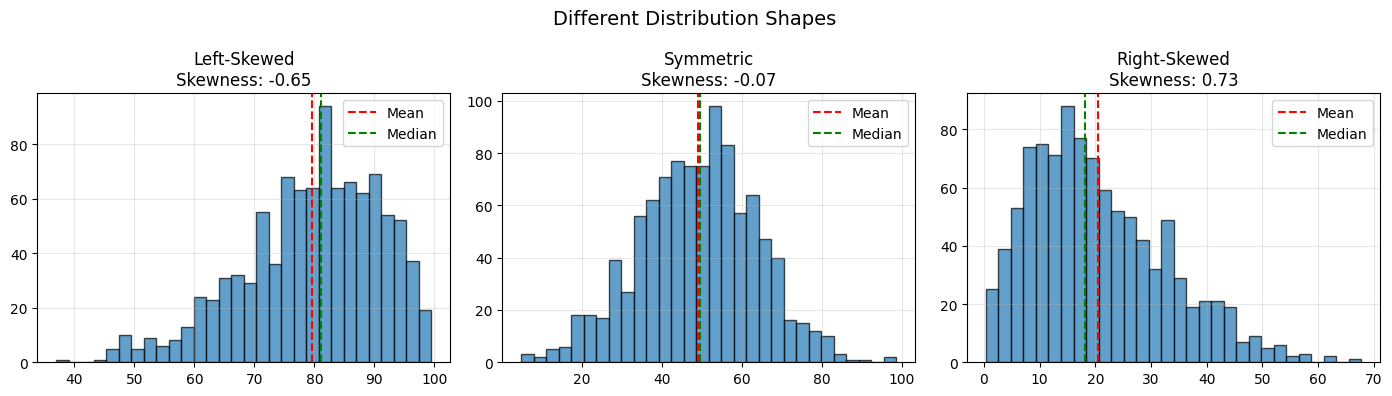

In [10]:
# Visualize different skewness
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left-skewed
left_skew = np.random.beta(8, 2, 1000) * 100
axes[0].hist(left_skew, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(left_skew), color='r', linestyle='--', label='Mean')
axes[0].axvline(np.median(left_skew), color='g', linestyle='--', label='Median')
axes[0].set_title(f'Left-Skewed\nSkewness: {stats.skew(left_skew):.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Symmetric
symmetric = np.random.normal(50, 15, 1000)
axes[1].hist(symmetric, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(symmetric), color='r', linestyle='--', label='Mean')
axes[1].axvline(np.median(symmetric), color='g', linestyle='--', label='Median')
axes[1].set_title(f'Symmetric\nSkewness: {stats.skew(symmetric):.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Right-skewed
right_skew = np.random.beta(2, 8, 1000) * 100
axes[2].hist(right_skew, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(np.mean(right_skew), color='r', linestyle='--', label='Mean')
axes[2].axvline(np.median(right_skew), color='g', linestyle='--', label='Median')
axes[2].set_title(f'Right-Skewed\nSkewness: {stats.skew(right_skew):.2f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Different Distribution Shapes', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Data Summary (Pandas)

In [11]:
# Real data example
df = pd.DataFrame({
    'age': np.random.randint(20, 65, 100),
    'income': np.random.randint(30000, 150000, 100),
    'experience': np.random.randint(0, 40, 100)
})

print("First 5 rows:")
print(df.head())
print(f"\nShape: {df.shape}")

First 5 rows:
   age  income  experience
0   54   52578           0
1   58   42787           2
2   57  102048          20
3   54   82879          22
4   55   40596           8

Shape: (100, 3)


In [12]:
# Comprehensive summary
summary = df.describe()
print("Statistical Summary:")
print(summary)
print(f"\nInterpretation:")
print(f"  count: non-null values")
print(f"  mean: average")
print(f"  std: standard deviation (spread)")
print(f"  min/max: range")
print(f"  25%, 50%, 75%: quartiles")

Statistical Summary:
              age         income  experience
count  100.000000     100.000000  100.000000
mean    44.800000   83167.630000   21.310000
std     12.533591   34989.340054   11.597366
min     22.000000   30026.000000    0.000000
25%     33.000000   51361.750000   12.000000
50%     46.000000   77425.500000   22.500000
75%     56.250000  115478.750000   31.250000
max     64.000000  146249.000000   39.000000

Interpretation:
  count: non-null values
  mean: average
  std: standard deviation (spread)
  min/max: range
  25%, 50%, 75%: quartiles


In [13]:
# Calculate custom statistics
print(f"\nCustom Statistics:")
print(f"Age skewness: {stats.skew(df['age']):.3f}")
print(f"Income skewness: {stats.skew(df['income']):.3f}")
print(f"\nCoefficient of Variation (CV):")
for col in df.columns:
    cv = df[col].std() / df[col].mean()
    print(f"  {col}: {cv:.3f}")
print(f"\nCV > 1 = high variability, CV < 1 = low variability")


Custom Statistics:
Age skewness: -0.211
Income skewness: 0.218

Coefficient of Variation (CV):
  age: 0.280
  income: 0.421
  experience: 0.544

CV > 1 = high variability, CV < 1 = low variability


---
## 5. Outlier Detection

In [14]:
# IQR method for outliers
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['income'] < lower_bound) | (df['income'] > upper_bound)]

print(f"IQR Method:")
print(f"  Q1: {Q1:.0f}")
print(f"  Q3: {Q3:.0f}")
print(f"  IQR: {IQR:.0f}")
print(f"  Lower bound: {lower_bound:.0f}")
print(f"  Upper bound: {upper_bound:.0f}")
print(f"  Number of outliers: {len(outliers)}")

IQR Method:
  Q1: 51362
  Q3: 115479
  IQR: 64117
  Lower bound: -44814
  Upper bound: 211654
  Number of outliers: 0



Z-Score Method:
  Threshold: |z-score| > 3
  Number of outliers: 0


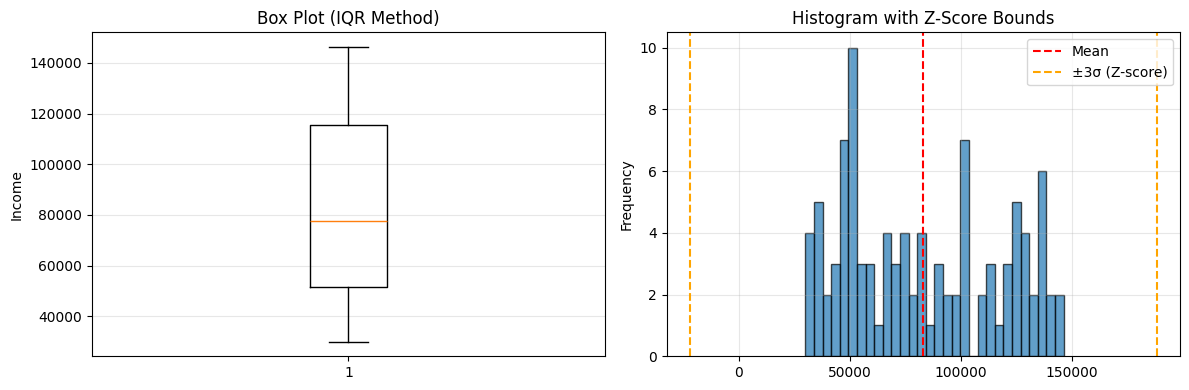

In [15]:
# Z-score method
from scipy.stats import zscore

z_scores = np.abs(zscore(df['income']))
outliers_zscore = df[z_scores > 3]

print(f"\nZ-Score Method:")
print(f"  Threshold: |z-score| > 3")
print(f"  Number of outliers: {len(outliers_zscore)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['income'])
axes[0].set_title('Box Plot (IQR Method)')
axes[0].set_ylabel('Income')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(df['income'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df['income'].mean(), color='r', linestyle='--', label='Mean')
axes[1].axvline(df['income'].mean() + 3*df['income'].std(), color='orange', 
                linestyle='--', label='±3σ (Z-score)')
axes[1].axvline(df['income'].mean() - 3*df['income'].std(), color='orange', linestyle='--')
axes[1].set_title('Histogram with Z-Score Bounds')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Central Tendency**: Mean, median, mode describe center
2. **Spread**: Variance, std dev, IQR measure variability
3. **Shape**: Skewness, kurtosis describe distribution
4. **Outliers**: Use IQR or Z-score to detect
5. **Summary**: `describe()` gives quick overview

---
## Your Turn

1. Load a dataset and compute all descriptive statistics
2. Identify and handle outliers
3. Compare distributions with different skewness

In [16]:
# Your code here